# Downloading JWST and Euclid data

In [1]:
import requests
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
# Replace this with your Dropbox shared link and modify to dl=1 at the end
dropbox_url = "https://www.dropbox.com/scl/fi/ibbxaq0fj9gkodsu0idow/EUC_MER_BGSUB-MOSAIC-NIR-J_TILE[…]Z_00.00.fits?rlkey=i1pnapefx2uj20v7y33lkl3e3&st=egn0es4i&dl=1"
# Stream the FITS file
response = requests.get(dropbox_url)
response.raise_for_status()  # Ensure successful request
# Read FITS file from memory
fits_file = BytesIO(response.content)
hdul = fits.open(fits_file)
# Display FITS file info
hdul.info()
# Access image data
image_data = hdul[0].data
hdul.close()

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      48   (10200, 10200)   float32   


In [12]:
folder_url = "https://caltech.box.com/s/3ykklf78uj89nm0wrc3tpwkkakpsmjju?dl=1"
response = requests.get(folder_url)
response.raise_for_status()

## Using Dropbox API

In [43]:
import requests
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import numpy as np
import pandas as pd
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D

In [2]:
home = "/Users/emily_ramey"
with open(f"{home}/secrets/dropbox_token") as token_file:
    token = token_file.read()
    dbx = dropbox.Dropbox(token.strip())
dbx

In [3]:
parent_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AK5SQfnqsfDYbqvUW1WVESI?rlkey=enfshikpl0r0wd8o2nz66i0km&e=1&st=brev767o&dl=0'
jwst_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/ANfH2VisN0vIphVxNIpO_ag/JWST?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=w3u4yz80&dl=0'
nisp_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AEiIbqfbMKqh6FRA2YouLHQ/NISP-J?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=hx3ru322&dl=0'

In [5]:
def get_shared_folder_metadata(url):
    """Get metadata of the shared folder."""
    shared_link = dropbox.files.SharedLink(url=url)
    try:
        folder_metadata = dbx.files_list_folder(path="", shared_link=shared_link)
        return folder_metadata.entries
    except dropbox.exceptions.ApiError as e:
        print(f"Error accessing shared folder: {e}")
        return []

# def download_file(file_path, local_path):
#     """Download a file from Dropbox to local storage."""
#     try:
#         metadata, res = dbx.files_download(path=file_path)
#         with open(local_path, "wb") as f:
#             f.write(res.content)
#             print(f"Downloaded: {file_path} -> {local_path}")
#     except dropbox.exceptions.ApiError as e:
#         print(f"Error downloading {file_path}: {e}")
#         # List and download files

files = get_shared_folder_metadata(jwst_url)
files[:3]

[FileMetadata(name='mosaic_nircam_f115w_COSMOS-Web_60mas_A4_v0_8_sci.fits', id='id:5_vKHfnAevQAAAAAAFlLZg', client_modified=datetime.datetime(2025, 2, 9, 21, 28, 42), server_modified=datetime.datetime(2025, 2, 10, 19, 15, 10), rev='0162dce86f0f02c00000002d79bc271', size=478281600, path_lower=None, path_display=None, parent_shared_folder_id='12207243889', media_info=None, symlink_info=None, sharing_info=FileSharingInfo(read_only=True, parent_shared_folder_id='12207243889', modified_by='dbid:AAAKZdAVm7hdpPL2i9nKMxvNYGOpfkysKHM'), is_downloadable=True, export_info=None, property_groups=None, has_explicit_shared_members=None, content_hash='b99062c4d14a389a3130cab34fcd07426c555c36e6f109dd475ccf7396b2c9d2', file_lock_info=None),
 FileMetadata(name='mosaic_nircam_f115w_COSMOS-Web_60mas_A2_v0_8_sci.fits', id='id:5_vKHfnAevQAAAAAAFlLZA', client_modified=datetime.datetime(2025, 2, 9, 21, 37, 35), server_modified=datetime.datetime(2025, 2, 10, 19, 15, 10), rev='0162dce86f0f02d00000002d79bc271', s

In [6]:
meta, res = dbx.sharing_get_shared_link_file(jwst_url, path='/'+files[0].name)
res

<Response [200]>

In [7]:
fits_file = BytesIO(res.content)
hdul = fits.open(fits_file)
# Display FITS file info
hdul.info()
# Access image data
image_data = hdul[0].data
image_header = hdul[0].header
hdul.close()

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SCI           1 PrimaryHDU      73   (9600, 12455)   float32   


In [8]:
wcs = WCS(image_header)
N1, N2 = image_data.shape # Data is in Y, X format, so Y axis is 12455 and X axis is 9600
# Corners for input into pixel_to_world are in X, Y format! (0,0), (9600,0), (0,12455), and (9600,12455)
corners = np.array([[0, 0], [N1, 0], [0, N2], [N1, N2]])
print(wcs.array_shape)
corners_sky = wcs.pixel_to_world(corners[:,1], corners[:,0])
corners_sky

(12455, 9600)


Set DATE-AVG to '2023-04-29T00:59:18.908' from MJD-AVG.
Set DATE-END to '2024-04-17T18:10:49.417' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     1.572297 from OBSGEO-[XYZ].
Set OBSGEO-H to 1265954850.776 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


<SkyCoord (ICRS): (ra, dec) in deg
    [(150.2769883 , 1.93775646), (150.34805533, 2.13280935),
     (150.12655384, 1.99248633), (150.19760458, 2.18754777)]>

In [11]:
test_coord = wcs.pixel_to_world([9599, 95600,0,1], [12454,1255,0,1])
test_coord.contained_by(wcs)

array([ True, False, False,  True])

In [14]:
# Load in the catalog
# Path to your FITS file
cat_path = '../catalog/COSMOS2020_FARMER_R1_v2.2_p3.fits'

# Load the FITS file
with fits.open(cat_path) as hdul:
    cat_data = hdul[1].data  # Adjust the HDU index if your data is not in the first extension

len(cat_data)

964506

In [57]:
cat_data.columns

ColDefs(
    name = 'ID'; format = 'K'; null = -99
    name = 'ALPHA_J2000'; format = 'D'; unit = 'deg'
    name = 'DELTA_J2000'; format = 'D'; unit = 'deg'
    name = 'X_MODEL'; format = 'D'; unit = 'pix'
    name = 'Y_MODEL'; format = 'D'; unit = 'pix'
    name = 'ERRX_MODEL'; format = 'D'; unit = 'pix'
    name = 'ERRY_MODEL'; format = 'D'; unit = 'pix'
    name = 'ALPHA_DETECTION'; format = 'D'; unit = 'deg'
    name = 'DELTA_DETECTION'; format = 'D'; unit = 'deg'
    name = 'FARMER_ID'; format = '8A'
    name = 'GROUP_ID'; format = 'K'; null = -99
    name = 'N_GROUP'; format = 'K'; null = -99
    name = 'MODEL_FLAG'; format = 'I'; null = -99
    name = 'SOLUTION_MODEL'; format = '20A'
    name = 'FLAG_HSC'; format = 'I'; null = -99
    name = 'FLAG_SUPCAM'; format = 'I'; null = -99
    name = 'FLAG_UDEEP'; format = 'I'; null = -99
    name = 'FLAG_UVISTA'; format = 'I'; null = -99
    name = 'FLAG_COMBINED'; format = 'K'; null = -99
    name = 'EBV_MW'; format = 'D'
    name = 'C

In [44]:
gal_coords = SkyCoord(cat_data['ALPHA_J2000'], cat_data['DELTA_J2000'], unit='deg')
idxs = np.where(gal_coords.contained_by(wcs))[0]
in_image = gal_coords[idxs]

In [45]:
in_image[0]

<SkyCoord (ICRS): (ra, dec) in deg
    (150.22271721, 2.12612693)>

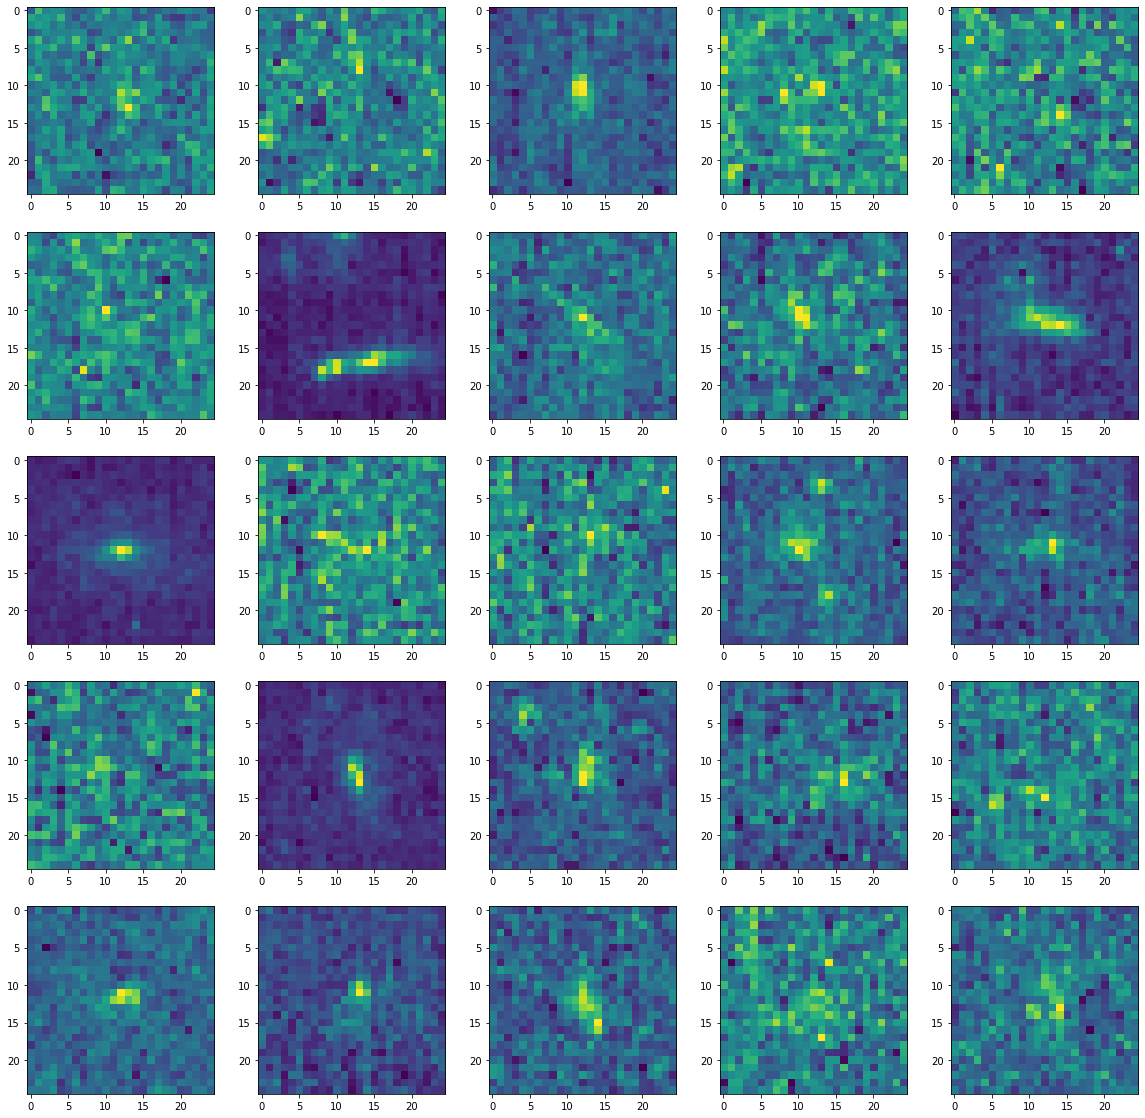

In [56]:
fig, axes = plt.subplots(5, 5, figsize=(20,20))
for i in range(25):
    clip = Cutout2D(image_data, in_image[i], size=25, wcs=wcs, mode='partial', fill_value=0)
    axes.flatten()[i].imshow(clip.data)

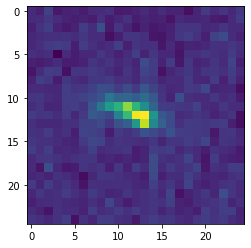

In [53]:
plt.imshow(clip.data)